In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
from glob import glob
import seaborn as sns
from PIL import Image
np.random.seed(123)

from sklearn.metrics import confusion_matrix
import itertools

from tensorflow import keras
from tensorflow.keras import regularizers
from tensorflow.keras.utils import to_categorical # used for converting labels to one-hot-encoding
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPool2D
from tensorflow.keras import backend as K
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [2]:
# Base data directory (relative to the notebook working directory)
base_skin_dir = os.path.join(os.getcwd(), 'data')
if not os.path.isdir(base_skin_dir):
    raise FileNotFoundError(f"Data directory not found: {base_skin_dir}.Place images and HAM10000_metadata.csv under this folder or adjust the path.")

In [3]:
# Discover image files: prefer subfolders (data/*/*.jpg), fallback to flat layout (data/*.jpg)
image_paths = glob(os.path.join(base_skin_dir, '*', '*.jpg'))
if len(image_paths) == 0:
    image_paths = glob(os.path.join(base_skin_dir, '*.jpg'))
if len(image_paths) == 0:
    raise FileNotFoundError(f'No .jpg images found under {base_skin_dir} (tried subfolders and root).')
# Map image_id (basename without extension) -> full path
imageid_path_dict = {os.path.splitext(os.path.basename(x))[0]: x for x in image_paths}

# This dictionary is useful for displaying more human-friendly labels later on

lesion_type_dict = {
    'nv': 'Melanocytic nevi',
    'mel': 'Melanoma',
    'bkl': 'Benign keratosis-like lesions ',
    'bcc': 'Basal cell carcinoma',
    'akiec': 'Actinic keratoses',
    'vasc': 'Vascular lesions',
    'df': 'Dermatofibroma'
}

In [4]:
# Read in the csv of metadata
metadata_path = os.path.join(base_skin_dir, 'HAM10000_metadata.csv')
if not os.path.exists(metadata_path):
    # also try notebook root in case CSV was placed there
    alt = os.path.join(os.getcwd(), 'HAM10000_metadata.csv')
    if os.path.exists(alt):
        metadata_path = alt
    else:
        raise FileNotFoundError(f'HAM10000_metadata.csv not found in {base_skin_dir} or notebook root ({os.getcwd()}).')

tile_df = pd.read_csv(metadata_path)
tile_df.tail()


,lesion_id,image_id,dx,dx_type,age,sex,localization
10010,HAM_0002867,ISIC_0033084,akiec,histo,40.0,male,abdomen
10011,HAM_0002867,ISIC_0033550,akiec,histo,40.0,male,abdomen
10012,HAM_0002867,ISIC_0033536,akiec,histo,40.0,male,abdomen
10013,HAM_0000239,ISIC_0032854,akiec,histo,80.0,male,face
10014,HAM_0003521,ISIC_0032258,mel,histo,70.0,female,back


In [5]:
# Create some new columns (path to image, human-readable name) and review them

tile_df['path'] = tile_df['image_id'].map(imageid_path_dict.get)
tile_df['cell_type'] = tile_df['dx'].map(lesion_type_dict.get) 
tile_df['cell_type_idx'] = pd.Categorical(tile_df['cell_type']).codes
tile_df.sample(5)

,lesion_id,image_id,dx,dx_type,age,sex,localization,path,cell_type,cell_type_idx
9725,HAM_0004376,ISIC_0024843,akiec,histo,70.0,female,face,c:\Users\ushre\Desktop\python\AI\project\Derma...,Actinic keratoses,0
6059,HAM_0003024,ISIC_0024768,nv,follow_up,35.0,female,trunk,c:\Users\ushre\Desktop\python\AI\project\Derma...,Melanocytic nevi,4
4540,HAM_0001659,ISIC_0026564,nv,follow_up,35.0,male,lower extremity,c:\Users\ushre\Desktop\python\AI\project\Derma...,Melanocytic nevi,4
3817,HAM_0004625,ISIC_0029346,nv,follow_up,40.0,male,upper extremity,c:\Users\ushre\Desktop\python\AI\project\Derma...,Melanocytic nevi,4
7914,HAM_0000443,ISIC_0034271,nv,histo,35.0,female,back,c:\Users\ushre\Desktop\python\AI\project\Derma...,Melanocytic nevi,4


In [6]:
# Get general statistics for the dataset

tile_df.describe(exclude=[np.number])


,lesion_id,image_id,dx,dx_type,sex,localization,path,cell_type
count,10015,10015,10015,10015,10015,10015,10015,10015
unique,7470,10015,7,4,3,15,10015,7
top,HAM_0000835,ISIC_0032258,nv,histo,male,back,c:\Users\ushre\Desktop\python\AI\project\Derma...,Melanocytic nevi
freq,6,1,6705,5340,5406,2192,1,6705


<Axes: xlabel='cell_type'>

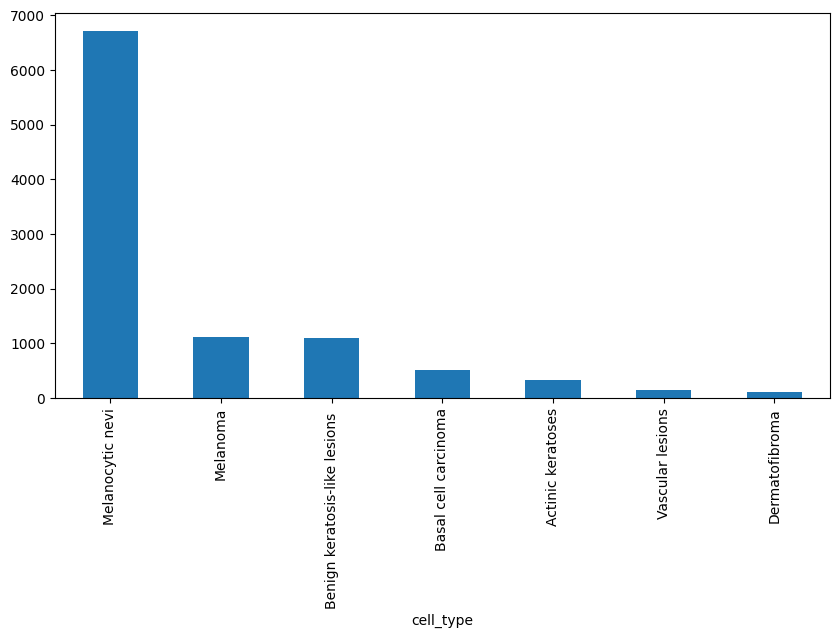

In [7]:
# Let's see the distribution of different cell types

fig, ax1 = plt.subplots(1, 1, figsize= (10, 5))
tile_df['cell_type'].value_counts().plot(kind='bar', ax=ax1)


<Axes: xlabel='cell_type'>

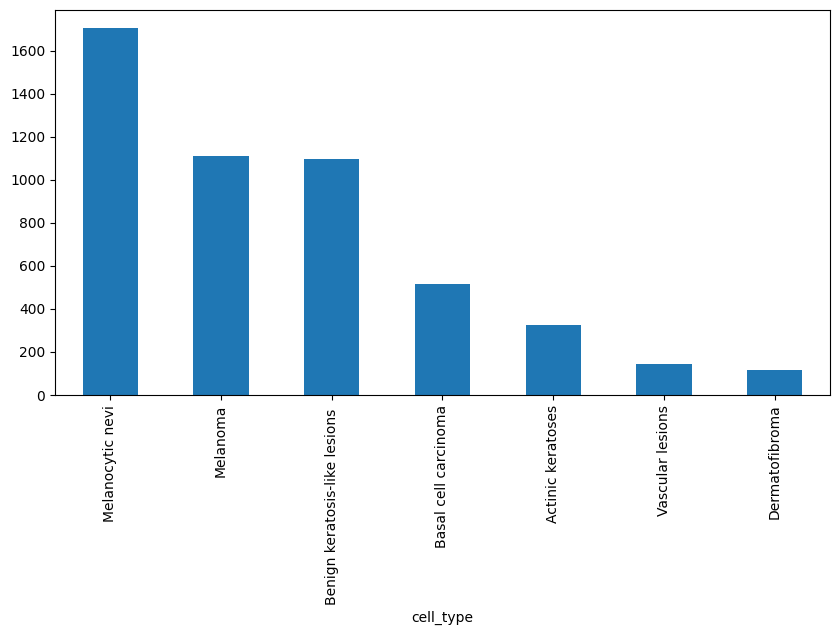

In [8]:
# Too many melanocytic nevi - let's balance it a bit!

tile_df = tile_df.drop(tile_df[tile_df.cell_type_idx == 4].iloc[:5000].index)

fig, ax1 = plt.subplots(1, 1, figsize= (10, 5))
tile_df['cell_type'].value_counts().plot(kind='bar', ax=ax1)



In [9]:
input_dims = (32, 32)
input_shape = input_dims + (3,)

# Load in all of the images into memory - this will take a while.  
# We also do a resize step because the original dimensions of 450 * 600 * 3 was too much for TensorFlow

tile_df['image'] = tile_df['path'].map(lambda x: np.asarray(Image.open(x).resize(input_dims)))

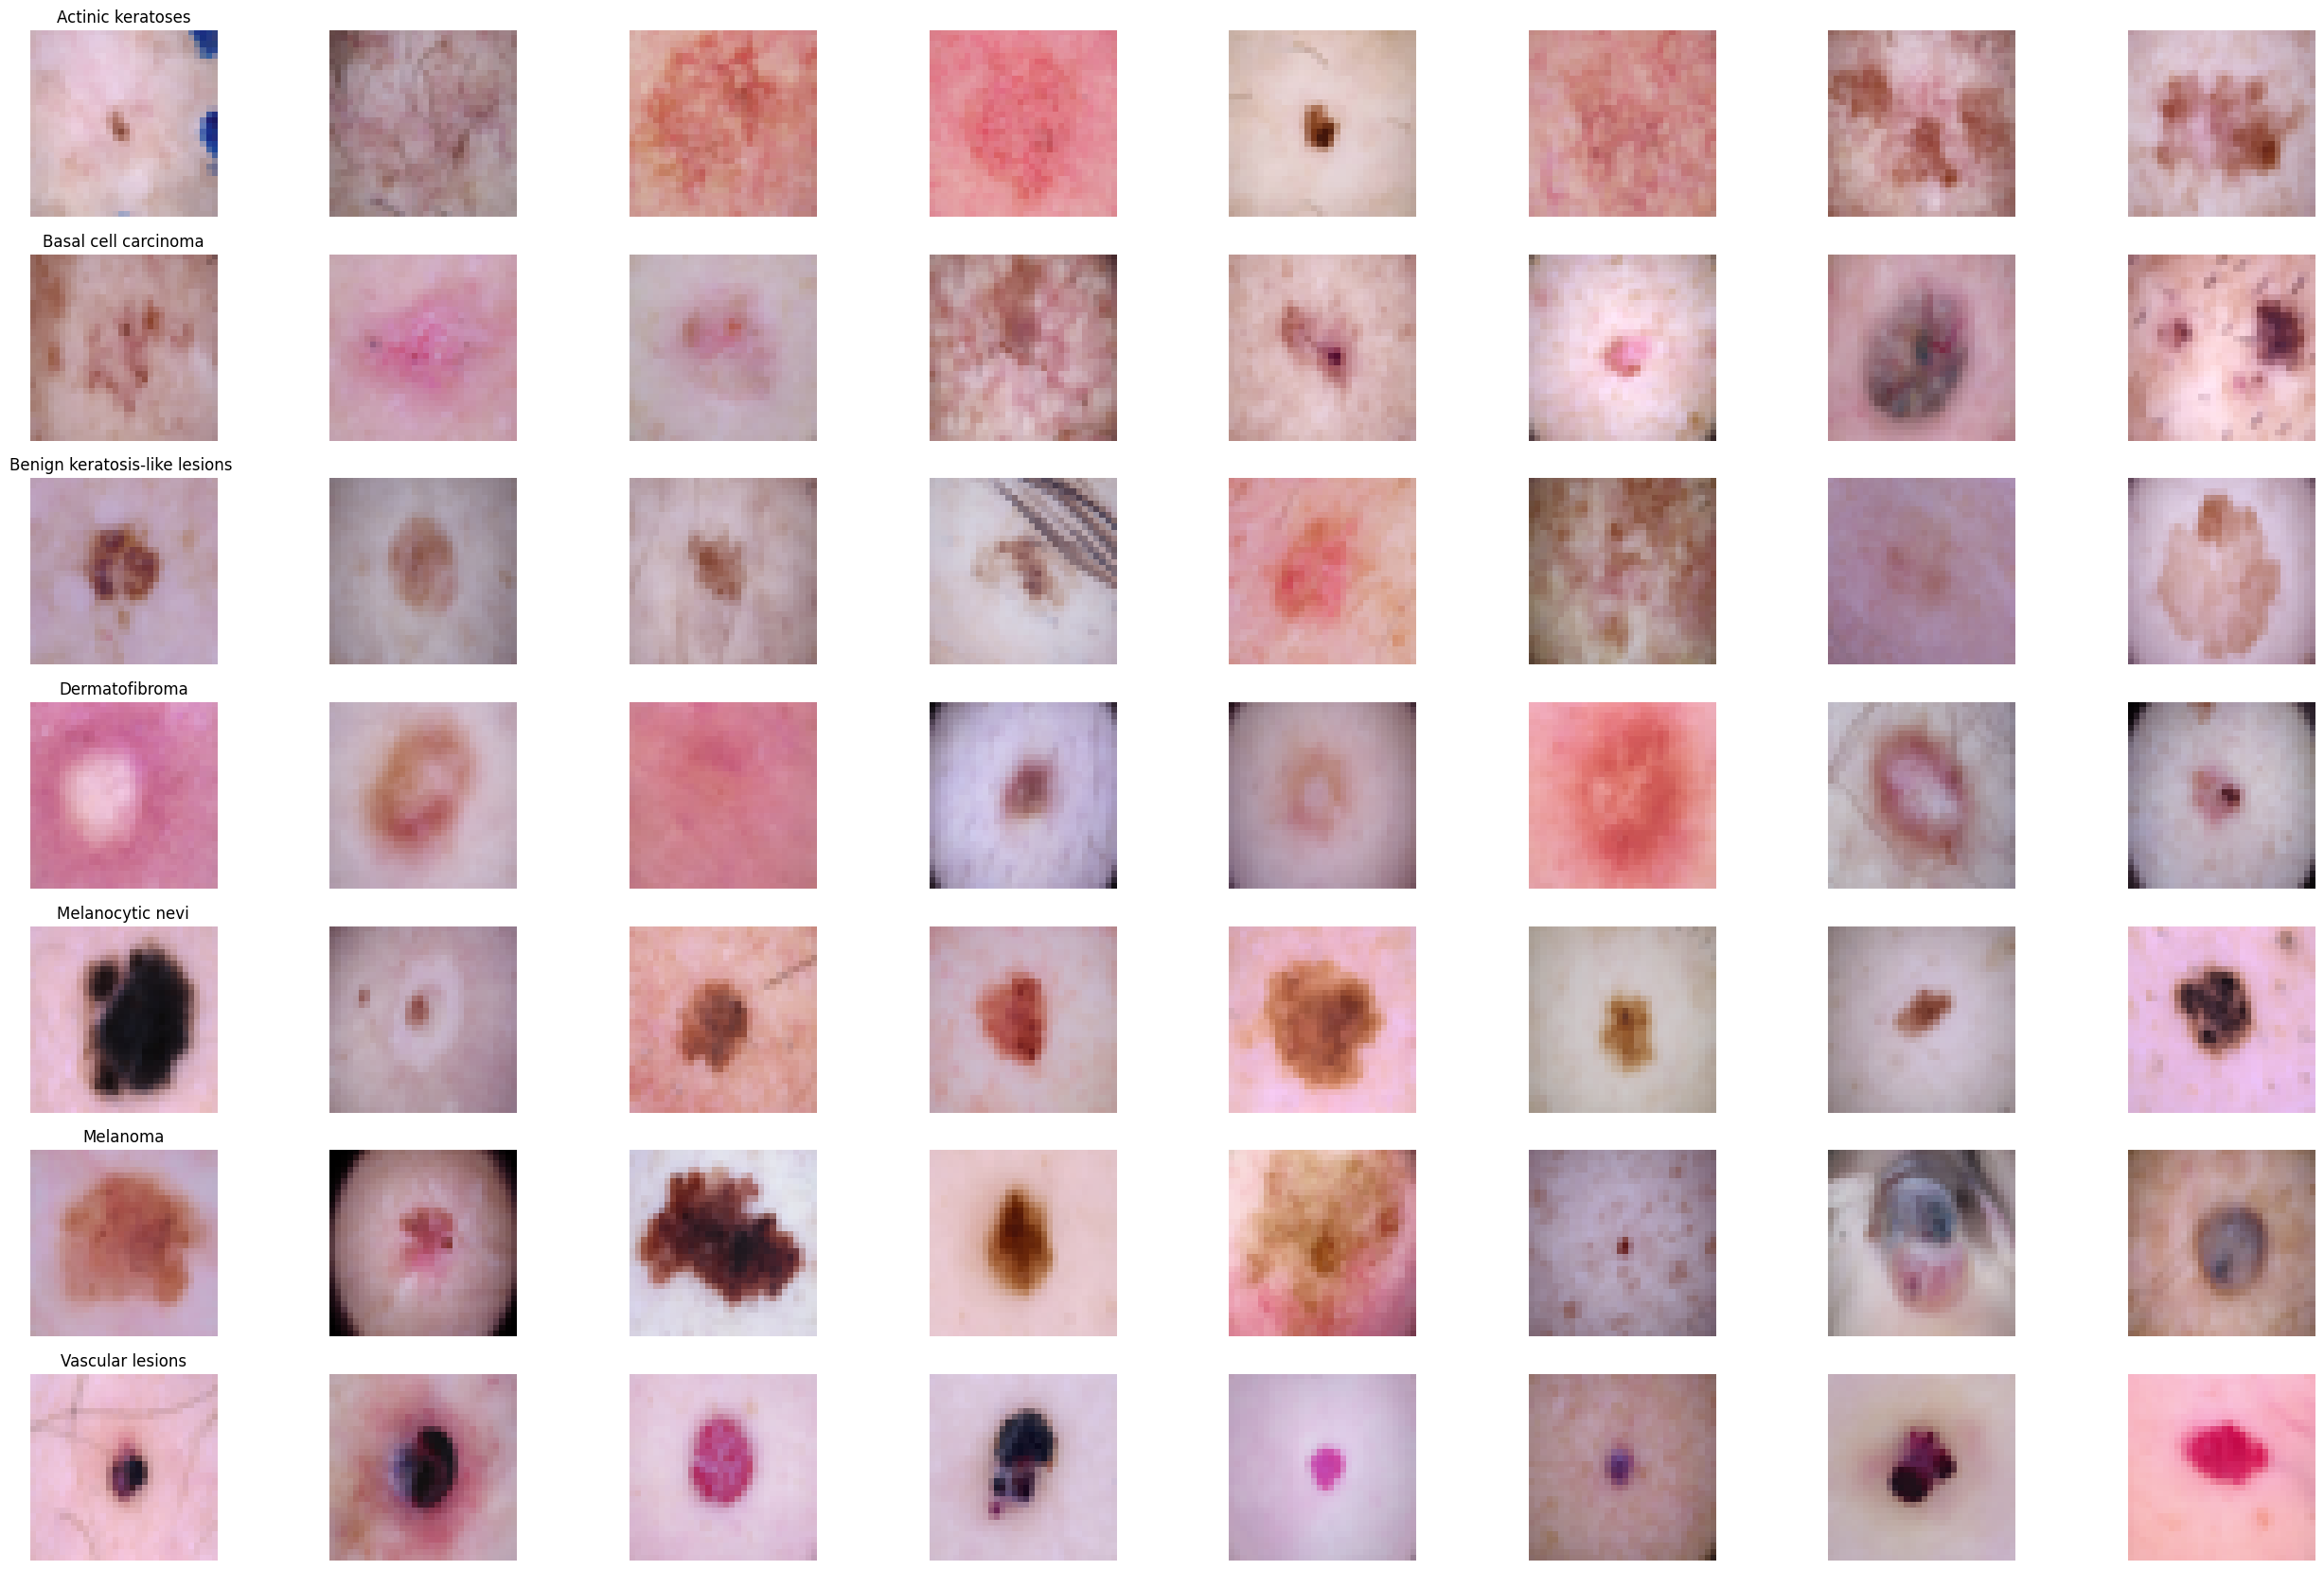

In [10]:
n_samples = 8
fig, m_axs = plt.subplots(7, n_samples, figsize = (4*n_samples, 3*7))
for n_axs, (type_name, type_rows) in zip(m_axs, 
                                         tile_df.sort_values(['cell_type']).groupby('cell_type')):
    n_axs[0].set_title(type_name)
    for c_ax, (_, c_row) in zip(n_axs, type_rows.sample(n_samples, random_state=2018).iterrows()):
        c_ax.imshow(c_row['image'])
        c_ax.axis('off')
fig.savefig('category_samples.png', dpi=300)

In [11]:
tile_df['image'].map(lambda x: x.shape).value_counts()

image
(32, 32, 3)    5015
Name: count, dtype: int64

In [12]:
y = tile_df.cell_type_idx
x_train_o, x_test_o, y_train_o, y_test_o = train_test_split(tile_df, y, test_size=0.25)

In [13]:
x_train = np.asarray(x_train_o['image'].tolist())
x_test = np.asarray(x_test_o['image'].tolist())

In [14]:
x_train_mean = np.mean(x_train)
x_train_std = np.std(x_train)

x_test_mean = np.mean(x_test)
x_test_std = np.std(x_test)

x_train = (x_train - x_train_mean)/x_train_std
x_test = (x_test - x_test_mean)/x_test_std

In [15]:
y_train = to_categorical(y_train_o, num_classes = 7)
y_test = to_categorical(y_test_o, num_classes = 7)

In [16]:
input_shape = (32, 32, 3)
num_classes = 7
batch_size = 32 
epochs = 15


In [17]:
model = Sequential()
model.add(Conv2D(32, kernel_size=(3, 3),
                 activation='relu',
                 input_shape=input_shape))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Dropout(0.25))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Dropout(0.25))
model.add(Flatten())
model.add(Dense(128, activation='relu',kernel_regularizer=regularizers.l2(0.01)))
model.add(Dropout(0.5))
model.add(Dense(num_classes, activation='softmax'))

c:\Users\ushre\Desktop\python\myenv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [18]:
model.compile(loss=keras.losses.categorical_crossentropy,
              optimizer=keras.optimizers.Adam(learning_rate=0.001),
              metrics=['accuracy'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 352,263 (1.34 MB)

 Trainable params: 352,263 (1.34 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
history = model.fit(x_train, y_train,
          batch_size=batch_size,
          epochs=epochs,
          verbose=1,
          validation_data=(x_test, y_test))

Epoch 1/15
118/118 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.3826 - loss: 2.4250 - val_accuracy: 0.4282 - val_loss: 1.7660
Epoch 2/15
118/118 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.4294 - loss: 1.6075 - val_accuracy: 0.4402 - val_loss: 1.4879
Epoch 3/15
118/118 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.4472 - loss: 1.4872 - val_accuracy: 0.4777 - val_loss: 1.4339
Epoch 4/15
118/118 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.4738 - loss: 1.4210 - val_accuracy: 0.4729 - val_loss: 1.3971
Epoch 5/15
118/118 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.4826 - loss: 1.4045 - val_accuracy: 0.5008 - val_loss: 1.4135
Epoch 6/15
118/118 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.5023 - loss: 1.3716 - val_accuracy: 0.4856 - val_loss: 1.3901
Epoch 7/15
118/118 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.5140 - loss: 1.3455 - val_accuracy: 0.5048 - val_loss: 1.3503
Epoch 8/15
118/118 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.5171 - loss: 1.3407 - val_accu

In [20]:
score = model.evaluate(x_test, y_test, verbose=0)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

Test loss: 1.316559910774231
Test accuracy: 0.5558213591575623


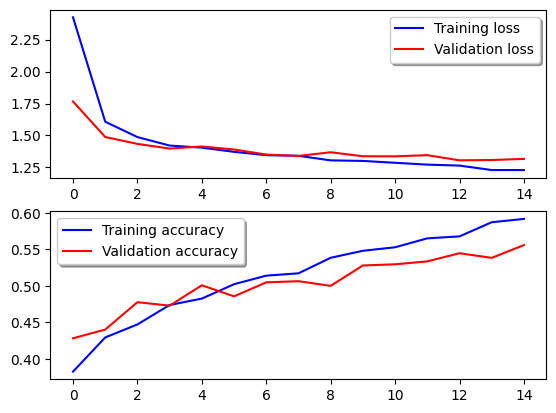

In [21]:
fig, ax = plt.subplots(2,1)
ax[0].plot(history.history['loss'], color='b', label="Training loss")
ax[0].plot(history.history.get('val_loss', history.history.get('val_loss')), color='r', label="Validation loss")
legend = ax[0].legend(loc='best', shadow=True)

# history keys differ across TF versions: try both 'acc'/'val_acc' and 'accuracy'/'val_accuracy'
acc_key = 'acc' if 'acc' in history.history else 'accuracy'
val_acc_key = 'val_acc' if 'val_acc' in history.history else 'val_accuracy'
ax[1].plot(history.history[acc_key], color='b', label="Training accuracy")
ax[1].plot(history.history[val_acc_key], color='r', label="Validation accuracy")
legend = ax[1].legend(loc='best', shadow=True)



40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


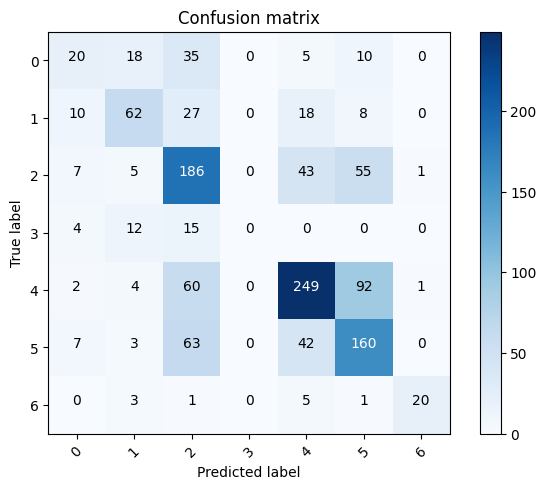

In [22]:
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j],
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

# Predict the values from the validation dataset
y_pred = model.predict(x_test)
# Convert predictions classes to one hot vectors 
y_pred_classes = np.argmax(y_pred,axis = 1) 
# Convert validation observations to one hot vectors
y_true = np.argmax(y_test,axis = 1) 
# compute the confusion matrix
confusion_mtx = confusion_matrix(y_true, y_pred_classes) 
# plot the confusion matrix
plot_confusion_matrix(confusion_mtx, classes = range(7)) 

Text(0, 0.5, 'Fraction classified incorrectly')

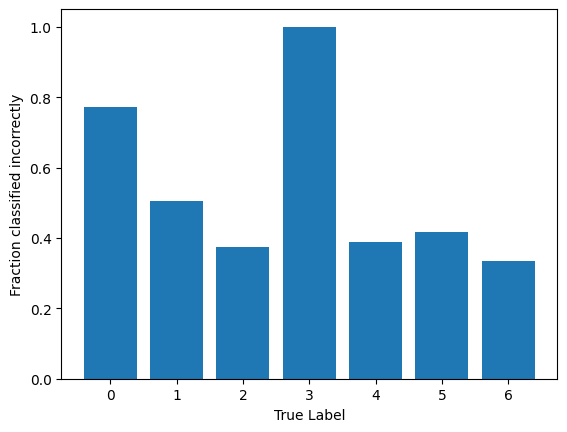

In [23]:
label_frac_error = 1 - np.diag(confusion_mtx) / np.sum(confusion_mtx, axis=1)
plt.bar(np.arange(7),label_frac_error)
plt.xlabel('True Label')
plt.ylabel('Fraction classified incorrectly')